# Transformer

Attention 단원에서는 encoder-decoder RNN에 attention을 결합해, query(디코더)가 key/value(인코더)를 조회하는 cross-attention을 배웠다. Transformer는 여기서 한 걸음 더 나아가, 순환 구조(RNN)를 완전히 제거하고 attention만으로 시퀀스를 처리하는 모델이다 (Vaswani et al., 2017, "Attention Is All You Need").

- 순환 신경망은 토큰을 순서대로 처리하므로 병렬화가 어렵고, 멀리 떨어진 토큰 간의 관계를 유지하기 어렵다.
- Transformer는 attention으로 모든 위치 쌍의 관계를 동시에 계산하므로 병렬 연산이 가능하고, 긴 문맥도 직접 참조할 수 있다.
- GPT, BERT 등 현대 언어 모델은 모두 Transformer에 기반한다.

이 단원에서는 Attention 단원의 attention을 self-attention으로 확장한 뒤, GPT 계열 모델과 같은 구조의 작은 decoder-only Transformer를 `tensorflow.keras`로 직접 만들어 본다. Karpathy의 `minGPT` / `nanoGPT` 아이디어를 단순화한 것으로, 목표는 성능 좋은 언어 모델을 만드는 것이 아니라 GPT 계열 모델의 핵심 구조를 눈으로 확인하는 것이다.

다루는 내용은 다음과 같다.

- Self-attention과 $\sqrt{d_k}$ 스케일링 (Attention 단원의 확장)
- 문자를 숫자 토큰으로 바꾸는 방법
- 다음 문자를 예측하는 언어 모델의 기본 구조
- causal self-attention의 의미
- token embedding과 positional embedding
- Transformer block의 구성
- 학습된 모델로 새 문자를 생성하고 attention을 시각화하는 방법

참고로 원 논문의 Transformer는 번역을 위한 encoder-decoder 구조다. 이 단원에서는 그보다 단순하면서 현대 언어 모델의 표준이 된 **decoder-only** 구조를 다루고, encoder-decoder 전체 구조는 다음 단원(보충 자료)에서 알아본다.

## Attention의 직관: 부드러운 dictionary 조회

Attention 단원에서 $\text{Attention}(Q,K,V) = \text{softmax}(QK^\top)V$ 계산을 이미 numpy로 직접 해봤다. 여기서는 같은 아이디어를 다른 각도에서 정리해 보자. Attention을 처음 볼 때 가장 어려운 것은 query, key, value가 왜 필요한지이다. 이미 알고 있는 Python dictionary와 비교하면 감을 잡기 쉽다.

```python
d = {"apple": 1.2, "banana": 0.5, "cherry": 3.0}
d["apple"]   # 1.2
```

Dictionary 조회는 query(`"apple"`)와 정확히 일치하는 key를 찾아 그 value 하나를 돌려준다.

Attention도 같은 구조다. query 하나로 여러 (key, value) 쌍을 조회한다. 차이는 다음과 같다.

| | dictionary | attention |
|---|---|---|
| 조회 방식 | key가 정확히 일치해야 함 | 모든 key와의 유사도를 계산 |
| 반환 값 | value 하나 | 유사도에 비례한 value들의 가중평균 |

즉, attention은 **부드러운(soft) dictionary 조회**다. "일치하면 1, 아니면 0"이 아니라 유사한 정도만큼 모든 value를 조금씩 가져온다. 유사도가 내적이라는 미분 가능한 연산으로 정의되므로, 무엇을 조회할지 자체를 gradient로 학습할 수 있다.

세 가지 역할을 정리하면 다음과 같다.

- **Query**: 지금 무엇을 찾고 싶은가 (조회하는 쪽)
- **Key**: 각 항목이 자신을 어떻게 나타내는가 (조회 대상의 색인)
- **Value**: 각 항목이 실제로 담고 있는 내용

### 복습: attention 계산

Attention 단원에서 이미 봤듯이 attention은 다음 세 단계로 계산된다.

$$
\text{scores} = QK^\top \;\longrightarrow\; \text{weights} = \text{softmax}(\text{scores}) \;\longrightarrow\; \text{output} = \text{weights} \cdot V
$$

query와 key의 내적으로 유사도를 구하고, softmax로 정규화한 뒤, 그 가중치로 value를 가중평균한다. Q, K, V는 각각 $W_q, W_k, W_v$ 가중치 행렬을 입력에 곱해 만든다는 것도 Attention 단원에서 확인했다.

Transformer는 여기에 한 가지를 추가한다. 바로 $\sqrt{d_k}$로 나누는 **스케일링**이다.

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

### 왜 스케일링이 필요한가

$Q$와 $K$의 각 성분이 평균 0, 분산 1로 독립이라고 하면, 내적 $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$의 분산은 대략 $d_k$에 비례해서 커진다. 차원 $d_k$가 커질수록 내적 값 자체도 커진다는 뜻이다.

내적 값이 크면 softmax의 입력값 차이가 커져서 가중치가 한 곳에 거의 100%로 쏠리는 **saturation**이 일어나기 쉽다. 이렇게 되면 softmax의 gradient가 거의 0이 되어 학습이 느려진다. $\sqrt{d_k}$로 나누면 내적 값의 분산을 대략 1로 되돌려 이 문제를 완화한다.

직접 확인해 보자. $d_k = 64$인 임의의 query 하나와 key 5개로 attention weight를 계산한다.

In [1]:
import numpy as np
import math
import tensorflow as tf

np.random.seed(0)

d_k = 64
q = np.random.randn(1, d_k)
K = np.random.randn(5, d_k)

scores = q @ K.T                      # 스케일링 없음
scaled_scores = scores / math.sqrt(d_k)

print("score의 표준편차 (스케일링 전):", np.std(scores).round(2), " (참고: sqrt(d_k) =", round(math.sqrt(d_k), 2), ")")
print()
print("스케일링 없음 -> softmax weights:", np.round(tf.nn.softmax(scores, axis=-1).numpy(), 3))
print("스케일링 적용 -> softmax weights:", np.round(tf.nn.softmax(scaled_scores, axis=-1).numpy(), 3))

score의 표준편차 (스케일링 전): 8.35  (참고: sqrt(d_k) = 8.0 )

스케일링 없음 -> softmax weights: [[0.    0.011 0.989 0.    0.   ]]
스케일링 적용 -> softmax weights: [[0.033 0.295 0.517 0.107 0.049]]


스케일링 없이 계산한 weight는 거의 하나의 key에만 1에 가깝게 쏠려 있고(saturation), 스케일링을 적용한 weight는 값이 조금 더 고르게 퍼져 있는 것을 볼 수 있다. $d_k$가 지금처럼 64, 실제 모델에서는 수백에 이르므로, 스케일링이 없으면 이 문제가 훨씬 심해진다.

### Self-attention과 multi-head attention

Attention 단원의 attention에서는 query가 디코더에서, key와 value가 인코더에서 나왔다(cross-attention). **Self-attention**은 query, key, value가 전부 같은 시퀀스에서 나온다는 점만 다르다. 같은 입력 $\mathbf{X}$에 서로 다른 가중치 행렬을 곱해 세 가지를 모두 만든다.

$$
\mathbf{Q} = \mathbf{X}W_q, \qquad \mathbf{K} = \mathbf{X}W_k, \qquad \mathbf{V} = \mathbf{X}W_v
$$

문장 안의 각 단어가 같은 문장의 다른 단어들을 참조하여 자신의 표현을 갱신하는 셈이다. 예를 들어 "그 동물은 길을 건너지 못했다. 그것은 너무 피곤했다"에서 "그것"의 표현은 "동물"을 강하게 참조하도록 학습될 수 있다.

**Multi-head attention**은 이 attention을 여러 개(head)를 병렬로 수행한 뒤 결과를 이어 붙이는 것이다. head마다 서로 다른 $W_q, W_k, W_v$를 가지므로, 서로 다른 종류의 관계를 나누어 볼 수 있다.

Attention 단원에서는 `Dot`, `Activation` 레이어를 직접 조합해 attention을 구현했다. Keras의 `layers.MultiHeadAttention`은 가중치 행렬 생성, head 분할, 스케일링, 결합을 한 번에 처리해 주는 레이어다. 이 단원에서는 이 레이어를 부품으로 사용하고, 내부 계산과 파라미터 수 분석은 다음 단원(보충 자료)에서 자세히 다룬다.

## 전체 구조 한눈에 보기

이 단원에서 만드는 모델은 작은 GPT다. GPT는 입력 문자를 왼쪽에서 오른쪽으로 읽고, 각 위치에서 다음 문자를 예측한다.

```text
문자열
  -> 문자 tokenizer로 정수 토큰열 변환
  -> token embedding + positional embedding
  -> Transformer block (causal self-attention + feed-forward) x N
  -> 다음 문자 점수(logits)
  -> 확률로 변환 후 sampling
  -> 새 문자 생성
```

중요한 점은 모델이 한 번에 문장 전체를 생성하는 것이 아니라, "지금까지 나온 문자들을 보고 다음 문자 하나"를 반복해서 예측한다는 것이다.

## 준비

TensorFlow가 필요하다. 설치되어 있지 않으면 아래 명령을 터미널이나 노트북 셀에서 한 번 실행한다.

```bash
pip install tensorflow
```

이 실습은 외부 데이터셋을 다운로드하지 않는다. 짧은 예제 문장을 여러 번 반복하여 작은 학습 데이터를 만든다.

기본 설정은 수업 중 실습이 버벅이지 않도록 작게 잡았다. 더 좋은 생성 결과를 보고 싶으면 마지막 연습 문제에서 층 수, 임베딩 차원, epoch 수를 조금씩 늘려 본다.

In [2]:
try:
    import numpy as np
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ModuleNotFoundError as e:
    raise ModuleNotFoundError("TensorFlow가 필요합니다. 먼저 `pip install tensorflow`를 실행한 뒤 다시 시도하세요.") from e

keras.utils.set_random_seed(42)
print(tf.__version__)

2.21.0


## 문자 단위 데이터 만들기

언어 모델은 토큰의 순서를 학습한다. 실제 대형 언어 모델은 복잡한 tokenizer를 사용하지만, 여기서는 원리를 쉽게 보기 위해 문자 하나를 하나의 토큰으로 사용한다.

예를 들어 `attention`이라는 단어는 여러 개의 문자 토큰으로 나뉘고, 각 문자는 정수 번호로 바뀐다.

In [3]:
text = """
To learn a transformer, start with attention.
Attention looks back at previous tokens.
A tiny model can still learn small patterns.
The model predicts the next character.
We train, sample, and inspect what changed.
""" * 30

chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return ''.join(itos[int(i)] for i in ids)

print('vocab_size =', vocab_size)
print('chars =', ''.join(chars))
print(encode('attention'))
print(decode(encode('attention')))

vocab_size = 30
chars = 
 ,.ATWabcdefghiklmnoprstuvwxy
[7, 24, 24, 11, 19, 24, 15, 20, 19]
attention


## 입력과 정답 만들기

언어 모델의 학습 목표는 현재까지의 토큰을 보고 다음 토큰을 맞히는 것이다.

예를 들어 입력이 `To learn`이라면 정답은 한 칸 오른쪽으로 이동한 `o learn `이 된다. 즉, 각 위치마다 “다음 문자”를 예측하도록 학습한다.

In [4]:
data = np.array(encode(text), dtype=np.int32)
block_size = 24
batch_size = 16

X = np.stack([data[i:i+block_size] for i in range(len(data) - block_size)])
y = np.stack([data[i+1:i+block_size+1] for i in range(len(data) - block_size)])

n = int(0.9 * len(X))
X_train, y_train = X[:n], y[:n]
X_val, y_val = X[n:], y[n:]

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10000).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)

print(X_train.shape, y_train.shape)
print(decode(X_train[0]))
print('--- target ---')
print(decode(y_train[0]))

(5810, 24) (5810, 24)

To learn a transformer,
--- target ---
To learn a transformer, 


## 기준 모델: Bigram 언어 모델

먼저 매우 단순한 기준 모델을 만든다. Bigram 모델은 현재 문자 하나만 보고 다음 문자를 예측한다.

이 모델은 문맥을 길게 보지 못한다. 따라서 나중에 만들 Transformer가 무엇을 개선하는지 비교하는 기준점으로 사용할 수 있다.

In [5]:
def build_bigram_model(vocab_size):
    inputs = keras.Input(shape=(None,), dtype='int32')
    logits = layers.Embedding(vocab_size, vocab_size)(inputs)
    return keras.Model(inputs, logits, name='bigram_language_model')

bigram = build_bigram_model(vocab_size)
bigram.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-2),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
)
bigram.summary()

Model: "bigram_language_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 30)       │           900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 900 (3.52 KB)

 Trainable params: 900 (3.52 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
bigram.fit(train_ds.take(40), validation_data=val_ds.take(10), epochs=2)

Epoch 1/2


C:\Users\KSLee\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 1/40 ━━━━━━━━━━━━━━━━━━━━ 21s 545ms/step - loss: 3.3979

32/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.8006   

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.6937 - val_loss: 2.1849


Epoch 2/2


 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 2.1960

26/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0728 

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0196 - val_loss: 1.8748


## 문자 생성 함수

모델은 각 위치에서 다음 문자에 대한 점수(logit)를 출력한다. 이 점수를 확률로 바꾸고, 그 확률에 따라 다음 문자를 하나 뽑는다.

이 과정을 반복하면 짧은 문장을 생성할 수 있다. `temperature`가 작으면 더 보수적으로, 크면 더 다양하게 생성한다.

In [7]:
def sample_from_logits(logits, temperature=1.0):
    logits = logits / temperature
    return tf.random.categorical(logits, num_samples=1)[0, 0].numpy()

def generate_text(model, start='\n', max_new_tokens=300, temperature=1.0):
    ids = encode(start)
    for _ in range(max_new_tokens):
        idx = np.array([ids[-block_size:]], dtype=np.int32)
        logits = model(idx, training=False)
        next_logits = logits[:, -1, :]
        next_id = sample_from_logits(next_logits, temperature=temperature)
        ids.append(next_id)
    return decode(ids)

print(generate_text(bigram, max_new_tokens=300, temperature=0.8))


Tuviok s pe ttsm
Tl pctokeaangvarmodenerttru
Tbarmprat ch toubitt.eratt smpe sfntaiorne, ara smo tha me st the l tted.
A arle,u catrng, llererbr, tatte marndA pectiontt s svinsperteWchit anster.
Ahedus.

Thate whh llod paile am
Atioo s.
Th lec.

Aiod.
Thamon,, t pWed t t s t cthain pan.xen checarn s


## Causal self-attention

Bigram 모델은 현재 문자 하나만 본다. Transformer는 이전에 나온 여러 토큰을 함께 참고한다. 이때 사용하는 핵심 연산이 self-attention이다.

다만 다음 문자를 예측하는 모델은 미래의 정답을 미리 보면 안 된다. 그래서 각 위치가 자기 자신과 과거 위치만 보도록 causal mask를 적용한다.

Keras의 `MultiHeadAttention`에서는 `use_causal_mask=True`로 이 마스크를 사용할 수 있다.

### Causal mask 그림

다음 문자 예측에서는 미래 문자를 보면 안 된다. 예를 들어 세 번째 입력 위치에서는 첫 번째부터 세 번째 문자까지를 이용해 네 번째 문자를 예측한다. 따라서 네 번째 이후의 문자를 미리 참조하면 정답을 훔쳐보는 셈이 된다.

causal mask는 각 위치가 자기 자신과 과거 위치만 보게 만든다.

```text
볼 수 있음: O, 볼 수 없음: X

          key 위치
          1  2  3  4  5
query 1   O  X  X  X  X
query 2   O  O  X  X  X
query 3   O  O  O  X  X
query 4   O  O  O  O  X
query 5   O  O  O  O  O
```

따라서 첫 번째 위치는 첫 번째 토큰만 보고, 다섯 번째 위치는 첫 번째부터 다섯 번째 토큰까지 볼 수 있다.

In [8]:
demo_x = tf.random.normal((1, 6, 8))
att = layers.MultiHeadAttention(num_heads=2, key_dim=4)
out, scores = att(
    demo_x,
    demo_x,
    use_causal_mask=True,
    return_attention_scores=True,
)

print('output shape:', out.shape)
print('attention score shape:', scores.shape)
print(np.round(scores[0, 0].numpy(), 3))

output shape: (1, 6, 8)
attention score shape: (1, 2, 6, 6)
[[1.    0.    0.    0.    0.    0.   ]
 [0.143 0.857 0.    0.    0.    0.   ]
 [0.141 0.143 0.716 0.    0.    0.   ]
 [0.419 0.057 0.333 0.192 0.    0.   ]
 [0.136 0.099 0.314 0.184 0.266 0.   ]
 [0.06  0.174 0.068 0.072 0.064 0.562]]


출력된 attention score 행렬을 히트맵으로 그려 보자.

causal mask 때문에 대각선 위(미래 위치)의 가중치가 정확히 0이 되어, 하삼각 형태가 나타난다.

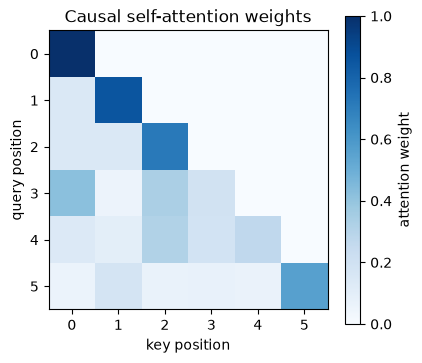

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4.5, 4))
plt.imshow(scores[0, 0].numpy(), cmap='Blues')
plt.colorbar(label='attention weight')
plt.xlabel('key position')
plt.ylabel('query position')
plt.title('Causal self-attention weights')
plt.show()

## Transformer block 만들기

이제 작은 GPT 모델을 구성한다. GPT는 encoder-decoder 구조가 아니라 decoder-only 구조를 사용한다. 여기서는 다음 구성 요소를 순서대로 쌓는다.

1. token embedding: 문자 번호를 벡터로 바꾼다.
2. positional embedding: 문자의 위치 정보를 더한다.
3. masked multi-head self-attention: 과거 토큰들을 참고한다.
4. feed-forward network: 각 위치의 표현을 한 번 더 변환한다.
5. residual connection과 layer normalization: 학습을 안정적으로 만든다.

참고로 여기서 positional embedding은 위치마다 학습되는 벡터를 사용한다(GPT 방식). 원 논문은 학습하지 않는 사인/코사인 함수 방식(sinusoidal positional encoding)을 사용하는데, 이는 다음 단원에서 다룬다.

### Transformer block의 내부 구조

Transformer block은 입력 표현을 조금씩 더 좋은 표현으로 바꾸는 층이다. 이 실습에서는 매우 작은 block을 사용한다.

```text
x ──→ LayerNorm ──→ Causal Multi-Head Self-Attention ──→ (+) ──→ h
└───────────────────────────────────────────────────────────┘   residual 1

h ──→ LayerNorm ──→ Feed-Forward Network ──→ (+) ──→ 출력
└───────────────────────────────────────────────┘   residual 2
```

- 두 개의 residual connection `(+)`는 이전 정보를 보존하면서 새 정보를 더하는 역할을 한다.
- Layer normalization은 각 단계의 값 범위를 정돈하여 학습이 불안정해지지 않게 한다.
- LayerNorm을 attention과 FFN **앞**에 두는 구조를 Pre-LN이라고 한다. 원 논문은 뒤에 두는 Post-LN 구조였지만, Pre-LN이 학습이 더 안정적이어서 GPT-2 이후 사실상 표준이 되었다. 아래 구현도 Pre-LN이다.

In [10]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, block_size, vocab_size, n_embd):
        super().__init__()
        self.token_embedding = layers.Embedding(vocab_size, n_embd)
        self.position_embedding = layers.Embedding(block_size, n_embd)

    def call(self, idx):
        T = tf.shape(idx)[1]
        positions = tf.range(0, T)
        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(positions)
        return tok_emb + pos_emb

class TransformerBlock(layers.Layer):
    def __init__(self, n_embd, n_head, dropout=0.1):
        super().__init__()
        self.ln1 = layers.LayerNormalization()
        self.attn = layers.MultiHeadAttention(
            num_heads=n_head,
            key_dim=n_embd // n_head,
            dropout=dropout,
        )
        self.ln2 = layers.LayerNormalization()
        self.ffn = keras.Sequential([
            layers.Dense(4 * n_embd, activation='relu'),
            layers.Dense(n_embd),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=False):
        norm_x = self.ln1(x)
        attn_out = self.attn(
            norm_x,
            norm_x,
            use_causal_mask=True,
            training=training,
        )
        x = x + attn_out
        x = x + self.ffn(self.ln2(x), training=training)
        return x

## 작은 GPT 모델 학습하기

아래 모델은 수업 중 실행하기 쉽도록 매우 작게 설정했다. 하지만 GPT 계열 모델의 핵심 구조는 모두 들어 있다.

출력층은 각 위치마다 다음 문자 후보 전체에 대한 점수를 만든다. 손실 함수는 정답 문자 번호와 예측 점수를 비교하는 sparse categorical crossentropy를 사용한다.

수업 중 빠르게 실행하기 위해 각 epoch에서 일부 batch만 사용한다. 더 오래 학습하고 싶으면 `take(60)` 값을 늘리거나 제거하면 된다.

In [11]:
def build_tiny_gpt(block_size, vocab_size, n_embd=64, n_head=4, n_layer=2, dropout=0.1):
    inputs = keras.Input(shape=(None,), dtype='int32')
    x = TokenAndPositionEmbedding(block_size, vocab_size, n_embd)(inputs)
    for _ in range(n_layer):
        x = TransformerBlock(n_embd, n_head, dropout)(x)
    x = layers.LayerNormalization()(x)
    logits = layers.Dense(vocab_size)(x)
    return keras.Model(inputs, logits, name='tiny_gpt')

gpt = build_tiny_gpt(
    block_size=block_size,
    vocab_size=vocab_size,
    n_embd=32,
    n_head=2,
    n_layer=1,
    dropout=0.1,
)

gpt.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
)

gpt.summary()

Model: "tiny_gpt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, None, 32)       │         1,728 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, None, 32)       │        12,704 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, None, 32)       │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 30)       │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,486 (60.49 KB)

 Trainable params: 15,486 (60.49 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
gpt.fit(train_ds.take(60), validation_data=val_ds.take(10), epochs=3)

Epoch 1/3


 1/60 ━━━━━━━━━━━━━━━━━━━━ 1:50 2s/step - loss: 3.8031

19/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.0711 

37/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8876

58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7084

...

Epoch 3/3


 1/60 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.3891

21/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3189 

40/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2496

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1697 - val_loss: 0.6941


## Bigram과 정량적으로 비교하기

학습이 짧아 생성 문장이 아직 어색하더라도, validation loss를 비교하면 개선을 수치로 확인할 수 있다.

loss는 다음 문자에 대한 cross-entropy이므로, 낮을수록 다음 문자를 잘 맞힌다는 뜻이다. 문맥을 한 글자만 보는 bigram보다 여러 글자를 보는 Transformer의 loss가 낮게 나오는지 확인해 보자.

여기서 validation loss는 새로운 문장에 대한 일반화 성능이라기보다, 동일한 짧은 말뭉치에서 Transformer가 bigram 모델보다 문맥을 더 잘 학습하는지를 비교하기 위한 값이다. (`text`를 그대로 30번 반복한 뒤 셔플 없이 순서대로 나눴으므로, validation 구간도 학습에 쓰인 것과 같은 문단에서 나온다.)

In [13]:
bigram_loss = bigram.evaluate(val_ds, verbose=0)
gpt_loss = gpt.evaluate(val_ds, verbose=0)

print(f"Bigram validation loss : {bigram_loss:.3f}")
print(f"GPT    validation loss : {gpt_loss:.3f}")

Bigram validation loss : 1.885


GPT    validation loss : 0.712


## 학습된 모델로 생성하기

학습이 끝난 뒤 같은 생성 함수를 사용해 문자를 생성한다. 처음에는 완벽한 영어 문장이 나오지 않을 수 있다. 그러나 Bigram 모델보다 반복되는 단어, 공백, 문장 구조를 더 잘 흉내 내는지 비교해 볼 수 있다.

짧게 학습한 모델은 아직 철자가 흔들릴 수 있다. `temperature`를 조금 낮추면 더 보수적이고 반복적인 문장이 나오며, epoch 수를 늘리면 말뭉치의 문장 패턴을 더 잘 따라간다.

In [14]:
print(generate_text(gpt, start="To ", max_new_tokens=500, temperature=0.6))

To smel ar, ansacan llll parnsa smple, prnstailernsmodel caca ckten iraiformor, startainformerns stillearn smodel pre, st nctainsthe model s predicts what chatet gerrarn, mailtarnsamopr, stat wh aet chat pilran, samanple, spr starn
The model arn sarar.
The mor, an stat nswhat cWaterair atin, sampllel pandecarn s.
The morararttins.
The model preticts nhechaion s matttelrner.
The model predicts ts what cthaien charangatttionenrmodercks.
A tin lksfoorecks Te mel sdecact n theen ctiorn s.
The model pre


## 학습된 attention 들여다보기

학습된 모델이 실제로 어디를 참조하는지 attention weight를 시각화해 보자.

첫 번째 Transformer block에서 attention score를 꺼내, head들의 평균을 히트맵으로 그린다. 행이 query(예측하는 위치), 열이 key(참조되는 위치)다.

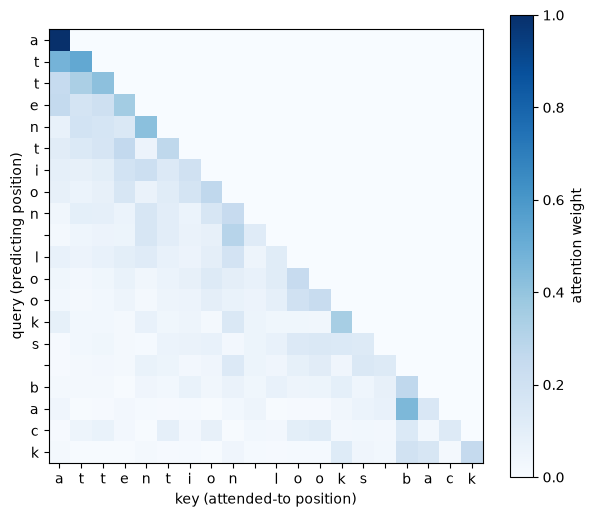

In [15]:
def attention_heatmap(model, prompt):
    ids = np.array([encode(prompt)], dtype=np.int32)

    emb_layer = next(l for l in model.layers if isinstance(l, TokenAndPositionEmbedding))
    block = next(l for l in model.layers if isinstance(l, TransformerBlock))

    x = emb_layer(ids)
    norm_x = block.ln1(x)
    _, att_scores = block.attn(norm_x, norm_x, use_causal_mask=True,
                               return_attention_scores=True)
    w = att_scores[0].numpy().mean(axis=0)   # head 평균, shape (T, T)

    tokens = list(prompt)
    plt.figure(figsize=(7, 6))
    plt.imshow(w, cmap='Blues')
    plt.xticks(range(len(tokens)), tokens)
    plt.yticks(range(len(tokens)), tokens)
    plt.xlabel('key (attended-to position)')
    plt.ylabel('query (predicting position)')
    plt.colorbar(label='attention weight')
    plt.show()

attention_heatmap(gpt, "attention looks back")

행(query)마다 어느 열(key)이 진한지 살펴보자. 하삼각 구조는 causal mask 때문이고, 그 안에서 진한 칸이 모델이 학습으로 얻은 참조 패턴이다.

작게 학습한 모델이라 패턴이 뚜렷하지 않을 수 있다. epoch 수를 늘려 다시 학습한 뒤 이 그림을 다시 그리면, 공백이나 자주 나오는 문자 조합에 집중하는 패턴이 점점 뚜렷해지는 것을 관찰할 수 있다.

## 연습 문제

1. `block_size`를 8, 16, 64로 바꾸면 생성 결과가 어떻게 달라지는가?
2. `n_layer`를 1에서 4로 늘리면 loss와 학습 시간이 어떻게 달라지는가?
3. `n_head`를 1로 줄이면 multi-head attention의 효과가 어떻게 달라지는가?
4. `use_causal_mask=False`로 바꾸면 왜 언어 모델 학습에서 문제가 되는가?
5. 예제 말뭉치를 직접 바꾸고, 모델이 어떤 패턴을 먼저 배우는지 관찰하라.
6. feed-forward network의 `relu`를 `gelu`로 바꾸어 보고 결과를 비교하라.
7. `temperature`를 0.5, 1.0, 1.5로 바꾸면 생성 문장이 어떻게 달라지는가?
8. 학습 epoch 수를 늘려 다시 학습한 뒤 `attention_heatmap`을 다시 그려 보라. attention 패턴이 어떻게 달라지는가?

## 정리

이 실습에서 만든 모델은 작지만 GPT 계열 모델의 핵심 부품을 포함한다.

- token embedding
- positional embedding
- causal self-attention
- multi-head attention
- residual connection
- layer normalization
- feed-forward network
- autoregressive generation

실제 GPT는 같은 아이디어를 훨씬 큰 데이터, 더 많은 층, 더 큰 embedding dimension으로 확장한 모델이라고 볼 수 있다.

이 단원의 모델은 decoder-only 구조였다. 번역처럼 입력 시퀀스와 출력 시퀀스가 서로 다른 문제에서는 인코더와 디코더를 모두 사용하는 encoder-decoder 구조를 쓴다. 원 논문의 encoder-decoder Transformer, sinusoidal positional encoding, multi-head attention의 내부 계산과 파라미터 수는 다음 단원(보충 자료)에서 다룬다.